# **k-Armed Bandit Problem**


### **Assignment 1 - Reinforcement Learning - MSc. Computer Science, AUEB [2025-2026]**


> Maria Schoinaki, MSc Student
>
> Department of Informatics, Athens University of Economics and Business
>
> mar.schoinaki@aueb.gr

## Imports

In [1]:
import numpy as np
import copy
import matplotlib.pyplot as plt
from tqdm import tqdm 

## Action Selection Algorithms

---

### 1. **ε-greedy Method**
For \( $0 \leq \varepsilon \leq 1 $\):

$$
A_t =
\begin{cases}
\displaystyle \arg\max_a Q_t(a), & \text{with probability } 1 - {\color{#bc5090}\varepsilon}, \\[8pt]
\text{a random action from } A, & \text{with probability } {\color{#bc5090}\varepsilon}.
\end{cases}
$$

- **Intuition:** Exploit the best-known action most of the time, but occasionally explore.  
- **Parameters:**  
  - \( $Q_t(a) $ \): estimated value of action \( $a$ \) at time \( $t$ \)  
  - \( $\varepsilon $ \): exploration rate  

---

### 2. **Upper Confidence Bound (UCB)**

$$
A_t = \arg\max_a \left(
Q_t(a) + {\color{#bc5090}c}\,\sqrt{\frac{\ln t}{N_t(a)}}
\right), \quad {\color{#bc5090}c} > 0
$$

- **Intuition:** Balance exploitation and exploration via an optimism-in-face-of-uncertainty approach.  
- **Parameters:**  
  - \( $Q_t(a)$ \): estimated value of action \( $a$ \) at time \( $t$ \)  
  - \( $N_t(a)$ \): number of times action \( $a$ \) has been chosen up to time \( $t$ \)  
  - \( $c$ \): exploration coefficient controlling the width of the confidence bound  

---

### 3. **Stochastic Gradient Ascent (Softmax Preferences)**

1. Initialize: \( $H_1(a) = 0, \; \forall a \in A $\)
2. At time \( t \), select action according to the **Softmax distribution**:
   $$
   \pi_t(a) = \frac{e^{H_t(a)}}{\sum_{b \in A} e^{H_t(b)}}
   $$
3. After selecting \( $A_t$ \) and observing reward \( $R_t$ \) at time \( $t$ \), update preferences:
   $$
   H_{t+1}(A_t) = H_t(A_t) + {\color{#bc5090}\alpha}\,(R_t - \bar{R}_t)\,(1 - \pi_t(A_t))
   $$
   $$
   H_{t+1}(a) = H_t(a) - {\color{#bc5090}\alpha}\,(R_t - \bar{R}_t)\,\pi_t(a), \quad \forall a \neq A_t
   $$

- **Intuition:** Learn a preference for actions based on their relative performance, using a differentiable softmax policy.  
- **Parameters:**  
  - \( $H_t(a)$ \): preference for action \( $a$ \) at time \( $t$ \)
  - \( $\alpha$ \): learning rate  
  - \( $\bar{R}_t$ \): average reward baseline \( $t$ \) (reduces variance)  


In [ ]:
class Strategy:
    def selected_action(self, params):
        pass

class EpsilonGreedy(Strategy):
    def __init__(self, actions, initial_action_vals, reward_std, epsilon):
        import numpy as np
        self.actions = actions
        self.initial_action_vals = initial_action_vals
        self.reward_std = reward_std
        self.epsilon = float(epsilon)

    def selected_action(self, params):
        import numpy as np
        Q = params["action_value_estimate"]
        k = params.get("total_values", len(Q))
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, k)
        m = np.max(Q)
        best = np.flatnonzero(Q == m)       # random tie-break
        return np.random.choice(best)

        
class UpperConfidenceBound(Strategy):
    def __init__(self, actions, initial_action_vals, reward_std, c):
        import numpy as np
        self.actions = actions
        self.initial_action_vals = initial_action_vals
        self.reward_std = reward_std
        self.c = float(c)

    def selected_action(self, params):
        import numpy as np
        Q = params["action_value_estimate"]
        N = params["action_selections"]
        k = params.get("total_values", len(Q))

        # pick any untried arm first
        untried = np.where(N == 0)[0]
        if untried.size > 0:
            return np.random.choice(untried)

        t = int(np.sum(N)) + 1  # ensure t>=1
        ucb = Q + self.c * np.sqrt(np.log(t) / N)
        m = np.max(ucb)
        best = np.flatnonzero(ucb == m)
        return np.random.choice(best)

            
class Softmax_preference(Strategy):
    def __init__(self, actions, initial_action_vals, reward_std, learning_rate_alpha):
        self.actions = actions
        self.initial_action_vals = initial_action_vals
        self.reward_std = reward_std
        self.learning_rate_alpha = learning_rate_alpha
        
    def select_action(self, params):
        H = params["H"]
        R_bar = params["R_bar"]
        self.pi_distribution = np.exp(H)/sum(np.exp(H))
        selected_action = np.random.choice(self.actions, p=self.pi_distribution)
        reward = np.random.normal(self.initial_action_vals[selected_action.id], self.reward_std)
        
        H[selected_action.id] = H[selected_action.id] + self.learning_rate_alpha * (reward - R_bar)*(1-self.pi_distribution[selected_action.id])
        for a in self.actions:
            if a != selected_action:
                H[a.id] = H[a.id] - self.learning_rate_alpha * (reward - R_bar)*self.pi_distribution[a.id]
        
        return selected_action, reward 
        
class Action:
    def __init__(self, id, Q_0, step_function):
        self.id = id
        self.sum_of_rewards = 0
        self.num_of_times_selected = 0
        self.Q = Q_0
        self.step_function = step_function
    
    def calculate_estimate(self, new_reward):
        self.sum_of_rewards += new_reward
        self.num_of_times_selected += 1
        self.Q += (self.step_function(self.num_of_times_selected))*(new_reward - self.Q)
        return self.Q

In [3]:
import numpy as np
from tqdm import tqdm

class Experiment:
    @staticmethod
    def conduct_experiment(tasks, env_parameters, strategy_parameters):
        iters = env_parameters["iterations"]
        k     = env_parameters["num_of_bandits"]

        avg_reward = np.zeros(iters)
        pct_opt    = np.zeros(iters)

        if env_parameters.get("seed") is not None:
            np.random.seed(env_parameters["seed"])

        for task in tqdm(range(tasks)):
            # true action values q* ~ N(mean, 1)
            q_true = np.random.normal(env_parameters["real_value_mean"], 1.0, size=k)
            env_parameters["initial_action_vals"] = q_true

            # optimistic init if requested
            if strategy_parameters.get("Q_0") is None:
                Q0 = strategy_parameters["optimistic"] * (
                    q_true.max() + 3 * env_parameters["reward_std"]
                )
            else:
                Q0 = strategy_parameters["Q_0"]

            rewards, arms_sel, best_arms = Experiment._multiarmed_bandit(
                env_parameters={**env_parameters},
                strategy_parameters={**strategy_parameters, "Q_0": Q0},
            )

            avg_reward += (rewards - avg_reward) / (task + 1)
            pct_opt    += ((arms_sel == best_arms).astype(float) - pct_opt) / (task + 1)

        return avg_reward, pct_opt

    @staticmethod
    def _multiarmed_bandit(env_parameters, strategy_parameters):
        q_true     = np.array(env_parameters["initial_action_vals"], dtype=float)
        reward_std = env_parameters["reward_std"]
        iters      = env_parameters["iterations"]
        k          = env_parameters["num_of_bandits"]

        # optional nonstationarity
        if env_parameters["type"] == "nonstationary":
            perturb = env_parameters["perturb"]
            def perturb_vals(vals):
                return vals + np.random.normal(0.0, perturb, size=vals.shape)
        else:
            def perturb_vals(vals):
                return vals

        alpha = strategy_parameters.get("alpha", 0.1)
        Q     = np.full(k, strategy_parameters["Q_0"])
        step_fn = (lambda n: 1.0 / n) if strategy_parameters["value_estimate_update_rule"] == "mean" else (lambda n: alpha)
        actions = [Action(i, Q_0=Q[i], step_function=step_fn) for i in range(k)]

        N            = np.zeros(k)
        rewards      = np.zeros(iters)
        arms_selected= np.zeros(iters, dtype=int)
        best_arms    = np.zeros(iters, dtype=int)

        strat = strategy_parameters["strategy"].lower()

        if strat == "epsilon_greedy":
            eps = float(strategy_parameters["epsilon"])
            strategy_obj = EpsilonGreedy(actions, q_true, reward_std, eps)
            params = {"action_value_estimate": Q, "total_values": k}

        elif strat == "upper_confidence_bound":
            c = float(strategy_parameters["c"])
            strategy_obj = UpperConfidenceBound(actions, q_true, reward_std, c)
            params = {"action_value_estimate": Q, "action_selections": N, "total_values": k}

        elif strat == "softmax_preference":
            lr = float(strategy_parameters["learning_rate_alpha"])
            strategy_obj = Softmax_preference(actions, q_true, reward_std, lr)
            params = {
                "H": np.zeros(k),
                "R_bar": 0.0,
                "use_baseline": bool(strategy_parameters.get("baseline", True)),
            }

        else:
            raise ValueError(f"Unknown strategy: {strategy_parameters['strategy']}")

        for t in range(iters):
            best_arms[t] = int(np.argmax(q_true))

            if strat == "softmax_preference":
                strategy_obj.initial_action_vals = q_true

                selected_action, r = strategy_obj.select_action(params)
                a = int(selected_action.id)

                # update baseline only if enabled
                if params["use_baseline"]:
                    params["R_bar"] += (r - params["R_bar"]) / (t + 1)

            else:
                a = int(strategy_obj.selected_action(params))
                r = np.random.normal(q_true[a], reward_std)

            rewards[t]       = r
            arms_selected[t] = a

            # incremental Q update (sample-average or constant-α)
            Q[a] = actions[a].calculate_estimate(r)
            N[a] += 1

            # refresh decision params for next step
            if strat != "softmax_preference":
                params["action_value_estimate"] = Q
                if "action_selections" in params:
                    params["action_selections"] = N

            # drift if nonstationary
            q_true = perturb_vals(q_true)

        return rewards, arms_selected, best_arms

## Experiments

In the following experiments, the performance of several action-selection algorithms is evaluated using a collection of randomly generated **k-armed bandit tasks**.  

For each task, the true action values \( $q(a),\; a = 1, \dots, k $ \) are drawn independently from a normal (Gaussian) distribution with mean given by `real_value_mean` and a standard deviation of 1.  

At each time step \( $t$ \), the agent selects an action \( $A_t$ \) and receives a reward \( $R_t$ \), which is sampled from a normal distribution with mean \( $q(A_t)$ \) and standard deviation `reward_std`. This setup ensures that rewards remain stochastic even when the underlying action values are fixed.  

By averaging results over many independent bandit tasks, we obtain reliable estimates of each method’s expected performance. The averaged learning curves — showing both **average reward** and the **percentage of times the optimal action is selected** over `iterations` steps — illustrate how effectively and how quickly different algorithms learn from experience.


### $\varepsilon$-Greedy Action Selection: Comparison of Different $\varepsilon$ Values  
*(Replication of Figure 2.2 from Sutton & Barto, 2nd Edition)*

This experiment compares the performance of $\varepsilon$-greedy action selection with different values of $\varepsilon$ in the 10-armed testbed.  
Each curve shows the average performance over 2,000 independent bandit tasks, each run for 2,000 steps.  

The figure illustrates the trade-off between exploration and exploitation:  
- **$\varepsilon = 0$** (greedy) quickly exploits but risks suboptimal convergence.  
- **$\varepsilon = 0.01$** and **$\varepsilon = 0.1$** introduce increasing exploration, leading to higher long-term rewards.  

Results are averaged to show both **average reward** and **percentage of optimal actions** over time.


100%|██████████| 2000/2000 [00:42<00:00, 46.77it/s]


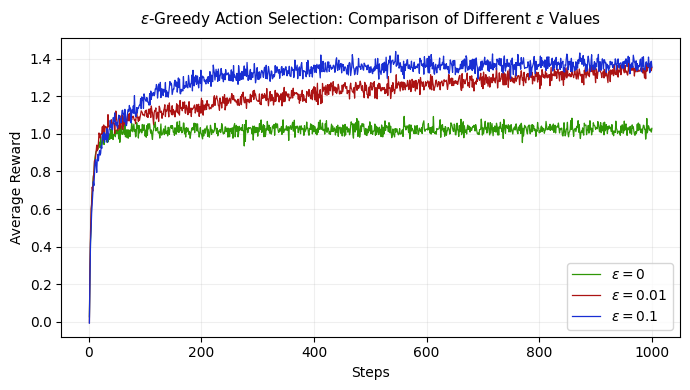

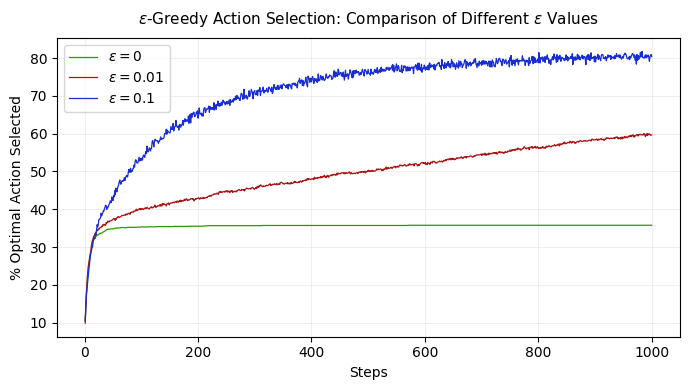

In [4]:
tasks = 2000
iterations = 1000
k = 10
seed = 42

env_parameters = {"seed": seed,  "real_value_mean": 0, "type":"stationary", "reward_std": 1, "iterations": iterations,  "num_of_bandits": k}
strategy_parameters = {"strategy": "epsilon_greedy", "optimistic": False, "value_estimate_update_rule": "mean", "epsilon": None, "alpha": 0.1}

epsilon_vals = [0, 0.01, 0.1]
metrics_per_epsilon = list()

for epsilon in epsilon_vals:
    strategy_parameters["epsilon"] = epsilon
    average_reward, percentage_optimal_action = Experiment.conduct_experiment(tasks, env_parameters, strategy_parameters)
    metrics_per_epsilon.append([average_reward, percentage_optimal_action])  

# Labels for the two subplots (average reward & % optimal action)
ylabels = [r'Average Reward', r'% Optimal Action Selected']
colors = ["#2f9706", "#AC1313", "#182ed3"]

for j in range(2):
    plt.figure(figsize=(7, 4))
    
    # Plot each ε-greedy curve
    for i, eps in enumerate(epsilon_vals):
        y_values = metrics_per_epsilon[i][j]
        # Convert to percentage for the optimal-action plot
        if j == 1:
            y_values = y_values * 100
        
        plt.plot(
            np.arange(1, iterations + 1),
            y_values,
            label=fr'$\varepsilon = {eps}$',
            color=colors[i % len(colors)],
            linewidth=0.9
        )
    
    # Titles and axes
    plt.title(r'$\varepsilon$-Greedy Action Selection: Comparison of Different $\varepsilon$ Values',
              fontsize=11, pad=10)
    plt.xlabel('Steps')
    plt.ylabel(ylabels[j])
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()  

### Optimistic vs. Realistic Initial Values  
*(Replication of Figure 2.3 from Sutton & Barto, 2nd Edition)*

This experiment compares the performance of **optimistic** and **realistic** initial action-value estimates  
in the 10-armed testbed using a **greedy (ε = 0)** action selection strategy.

Each curve shows the average over 2,000 independent bandit tasks,  
each running for 1,000 steps with rewards sampled from  
\( $R_t \sim \mathcal{N}(q_*(A_t), 1) $\), where \($ q_*(a) \sim \mathcal{N}(0, 1) $\).

- **Optimistic initialization**: \( Q_1(a) = 5.0 \) encourages early exploration  
  because all actions start with unrealistically high estimates.  
- **Realistic initialization**: \( Q_1(a) = 0.0 \) starts closer to the true mean reward,  
  leading to faster exploitation but potentially slower discovery of better actions.

The figure illustrates how **initial optimism** can serve as a simple form of exploration,  
even when no randomness (ε = 0) is added to action selection.


100%|██████████| 2000/2000 [00:43<00:00, 46.13it/s]


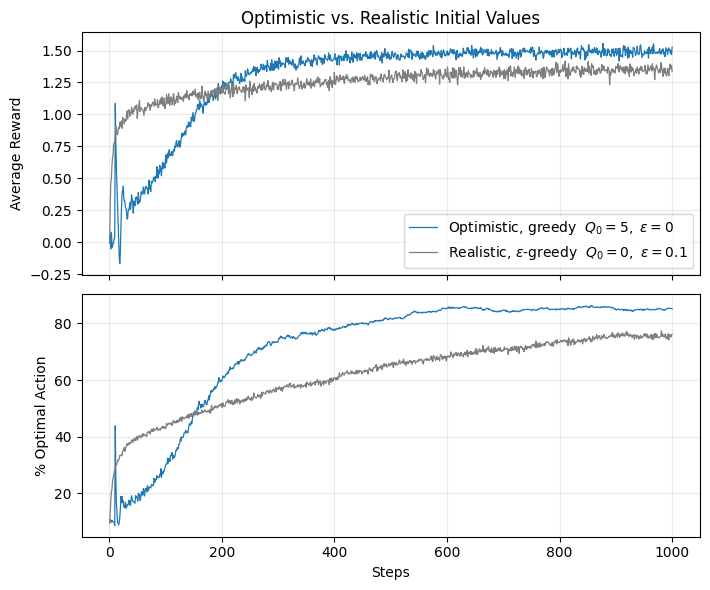

In [5]:
tasks = 2000
iterations = 1000
k = 10
seed = 42

env_parameters = {
    "seed": seed,
    "real_value_mean": 0,
    "type": "stationary",
    "reward_std": 1,
    "iterations": iterations,
    "num_of_bandits": k,
    "perturb": 0.0,  # stationary
}

def run_strategy(env_params, strat_params):
    avg, pct = Experiment.conduct_experiment(tasks, env_params, strat_params)
    return [avg, pct]

metrics_per_experiment = []

# --- 1. Optimistic greedy (Q0=5, ε=0)
optimistic_greedy = {
    "strategy": "epsilon_greedy",
    "Q_0": 5.0,
    "epsilon": 0.0,
    "alpha": 0.1,
    "value_estimate_update_rule": "exponential_decay",  # constant-α
    "optimistic": True,
}
metrics_per_experiment.append(
    run_strategy(copy.deepcopy(env_parameters), copy.deepcopy(optimistic_greedy))
)

# --- 2. Realistic ε-greedy (Q0=0, ε=0.1)
realistic_eps = {
    "strategy": "epsilon_greedy",
    "Q_0": 0.0,
    "epsilon": 0.1,
    "alpha": 0.1,
    "value_estimate_update_rule": "exponential_decay",
    "optimistic": False,
}
metrics_per_experiment.append(
    run_strategy(copy.deepcopy(env_parameters), copy.deepcopy(realistic_eps))
)

# ----------------------------------------------------
# Plot both average reward and % optimal action
# ----------------------------------------------------
labels = [
    r'Optimistic, greedy  $Q_0=5,\ \varepsilon=0$',
    r'Realistic, $\varepsilon$-greedy  $Q_0=0,\ \varepsilon=0.1$'
]
colors = ["#1f77b4", "#7f7f7f"]  # blue, gray

x = np.arange(1, iterations + 1)
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

# --- (a) Average Reward ---
for i, (avg, pct) in enumerate(metrics_per_experiment):
    axes[0].plot(x, avg, label=labels[i], color=colors[i], linewidth=0.9)
axes[0].set_ylabel('Average Reward')
axes[0].set_title('Optimistic vs. Realistic Initial Values')
axes[0].grid(alpha=0.25)
axes[0].legend()

# --- (b) % Optimal Action ---
for i, (avg, pct) in enumerate(metrics_per_experiment):
    axes[1].plot(x, pct * 100, label=labels[i], color=colors[i], linewidth=0.9)
axes[1].set_xlabel('Steps')
axes[1].set_ylabel('% Optimal Action')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


### UCB Action Selection: Comparison of Different $c$ Values  
*(Replication of Figure 2.4 from Sutton & Barto, 2nd Edition)*

We compare **Upper-Confidence-Bound (UCB)** action selection with different exploration constants  
\( $c \in \{0.5, 1, 2\}$ \) against **$\varepsilon$-greedy** with \( $\varepsilon = 0.1$ \) on the 10-armed testbed.

**Setup**
- 2,000 runs × 1,000 steps; \( $k=10$ \)
- True values \( $q_*(a) \sim \mathcal{N}(0,1)$ \); rewards \( $R_t \sim \mathcal{N}(q_*(A_t), 1)$ \)
- Action-value estimates use **sample averages** (no constant step-size)
- UCB scores: \( $Q(a) + c \sqrt{\frac{\ln t}{N(a)}}$ \), with untried arms forced first

**What to expect**
- UCB generally outperforms $\varepsilon$-greedy in average reward after the first \( $k$ \) steps.
- Larger \( $c$ \) → more exploration early; too large can slow convergence.
- The first \( $k$ \) steps are exploratory for UCB (each arm is tried once), hence the initial dip.


100%|██████████| 2000/2000 [00:42<00:00, 47.02it/s]


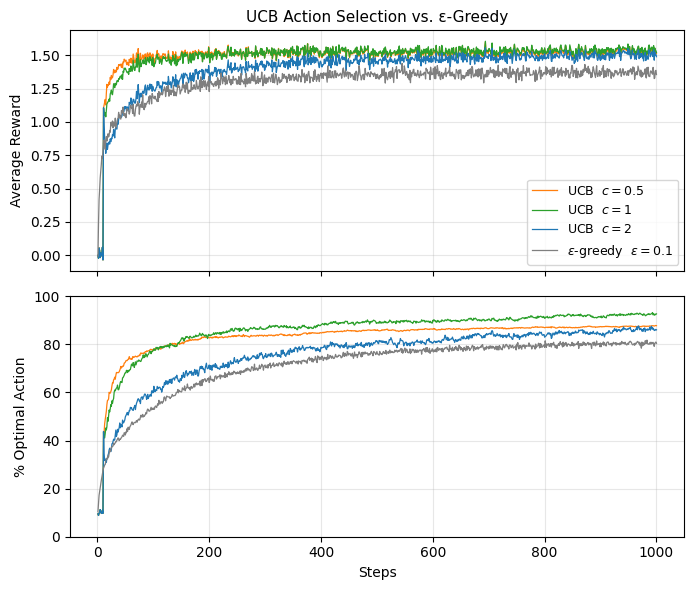

In [6]:
tasks = 2000
iterations = 1000
k = 10
seed = 42

env_parameters = {
    "seed": seed,
    "type": "stationary",
    "real_value_mean": 0,
    "reward_std": 1,
    "iterations": iterations,
    "num_of_bandits": k,
    "perturb": 0.0,   # stationary
}

def run_strategy(env_params, strat_params):
    avg, pct = Experiment.conduct_experiment(tasks, env_params, strat_params)
    return [avg, pct]

metrics_per_experiment = []

# --- 1. UCB for c = 0.5, 1, 2 ---
c_vals = [0.5, 1.0, 2.0]
for c in c_vals:
    strat = {
        "strategy": "upper_confidence_bound",
        "c": float(c),
        "Q_0": 0.0,
        "value_estimate_update_rule": "mean",
        "alpha": 0.1,
        "optimistic": False,
    }
    metrics_per_experiment.append(
        run_strategy(copy.deepcopy(env_parameters), copy.deepcopy(strat))
    )

# --- 2. ε-greedy ε=0.1 (for comparison) ---
eps_strat = {
    "strategy": "epsilon_greedy",
    "epsilon": 0.1,
    "Q_0": 0.0,
    "value_estimate_update_rule": "mean",
    "alpha": 0.1,
    "optimistic": False,
}
metrics_per_experiment.append(
    run_strategy(copy.deepcopy(env_parameters), copy.deepcopy(eps_strat))
)

# ------------------------------------------------------
# Plot: Average Reward and % Optimal Action (2 panels)
# ------------------------------------------------------
labels = [
    r'UCB  $c=0.5$',
    r'UCB  $c=1$',
    r'UCB  $c=2$',
    r'$\varepsilon$-greedy  $\varepsilon=0.1$',
]
colors = ["#ff7f0e", "#2ca02c", "#1f77b4", "#7f7f7f"]

x = np.arange(1, iterations + 1)
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

# --- (a) Average Reward ---
for (avg, pct), label, col in zip(metrics_per_experiment, labels, colors):
    axes[0].plot(x, avg, label=label, color=col, linewidth=0.9)
axes[0].set_ylabel('Average Reward')
axes[0].set_title('UCB Action Selection vs. ε-Greedy', fontsize=11)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=9)

# --- (b) % Optimal Action ---
for (avg, pct), label, col in zip(metrics_per_experiment, labels, colors):
    axes[1].plot(x, pct * 100, label=label, color=col, linewidth=0.9)
axes[1].set_xlabel('Steps')
axes[1].set_ylabel('% Optimal Action')
axes[1].set_ylim(0, 100)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Stochastic Gradient Ascent (Softmax Preferences): Comparison of Different $\alpha$ Values  
*(Replication of **Figure 2.5** from Sutton & Barto, 2nd Edition)*

We evaluate the **gradient bandit** (softmax-preference) algorithm for different learning
rates $\alpha \in \{0.1, 0.4\}$.

**Policy & Updates**
- Action probabilities:  
  $$
  \pi_t(a) \;=\; \frac{e^{H_t(a)}}{\sum_b e^{H_t(b)}}
  $$
- Preference updates (with baseline $\bar R_t$):  
  $$
  H_{t+1}(A_t)=H_t(A_t)+\alpha\,(R_t-\bar R_t)\,(1-\pi_t(A_t)),\qquad
  H_{t+1}(a)=H_t(a)-\alpha\,(R_t-\bar R_t)\,\pi_t(a)\ (a\neq A_t)
  $$
- Baseline tracked incrementally:  
  $$
  \bar R_{t+1}=\bar R_t+\frac{1}{t}\,(R_t-\bar R_t)
  $$

**Setup**
- 2,000 runs × 1,000 steps; $k = 10$
- True action values: $q_{*}(a) \sim \mathcal{N}(4, 1)$ *(shifted up as in the book)*
- Rewards: $R_t \sim \mathcal{N}\big(q_{*}(A_t),\,1\big)$
- Metric: **% Optimal Action** over time

**What to expect**
- Larger $\alpha$ (e.g., 0.4) usually learns faster early on but can be noisier.
- Using the **baseline** greatly reduces variance and yields better, smoother performance.
- Shifting rewards up by +4 **does not** change results when a baseline is used (it cancels out).


100%|██████████| 2000/2000 [01:24<00:00, 23.64it/s]


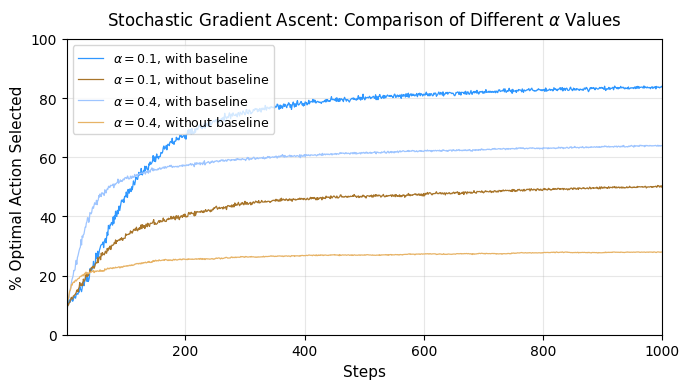

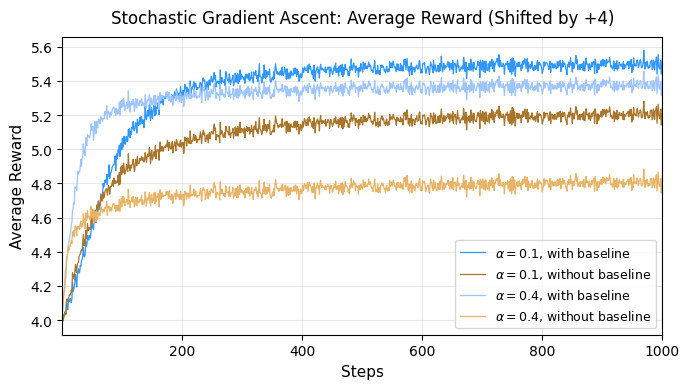

In [7]:
tasks = 2000
iterations = 1000
k = 10
seed = 42

env_parameters = {
    "seed": seed,
    "real_value_mean": 4,   # +4 shift
    "type": "stationary",
    "reward_std": 1,
    "iterations": iterations,
    "num_of_bandits": k,
    "perturb": 0.0,  # stationary
}

learning_rate_vals = [0.1, 0.4]
baseline_vals = [True, False]

metrics_per_experiment = []

for alpha in learning_rate_vals:
    for use_baseline in baseline_vals:
        strategy_parameters = {
            "strategy": "softmax_preference",
            "optimistic": False,
            "value_estimate_update_rule": "mean",   
            "learning_rate_alpha": alpha,
            "baseline": use_baseline,         
            "alpha": alpha,
            "Q_0": 0.0,
        }

        avg_reward, pct_opt = Experiment.conduct_experiment(
            tasks,
            copy.deepcopy(env_parameters),
            copy.deepcopy(strategy_parameters),
        )

        metrics_per_experiment.append([avg_reward, pct_opt])

colors = ["#2f97ff", "#a8752a", "#9ec5ff", "#e7b366"]


labels = [
    r'$\alpha = 0.1$, with baseline',
    r'$\alpha = 0.1$, without baseline',
    r'$\alpha = 0.4$, with baseline',
    r'$\alpha = 0.4$, without baseline',
]


plt.figure(figsize=(7, 4))
x = np.arange(1, iterations + 1)

for i, (_, pct_opt) in enumerate(metrics_per_experiment):
    plt.plot(
        x, pct_opt * 100,
        label=labels[i],
        color=colors[i % len(colors)],
        linewidth=0.9
    )

plt.title(r'Stochastic Gradient Ascent: Comparison of Different $\alpha$ Values',
          fontsize=12, pad=10)
plt.xlabel('Steps', fontsize=11)
plt.ylabel('% Optimal Action Selected', fontsize=11)
plt.xlim(1, iterations)
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


plt.figure(figsize=(7, 4))
for i, (avg_reward, _) in enumerate(metrics_per_experiment):
    plt.plot(
        x, avg_reward,
        label=labels[i],
        color=colors[i % len(colors)],
        linewidth=0.9
    )

plt.title(r'Stochastic Gradient Ascent: Average Reward (Shifted by +4)', fontsize=12, pad=10)
plt.xlabel('Steps', fontsize=11)
plt.ylabel('Average Reward', fontsize=11)
plt.xlim(1, iterations)
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


### Parameter Study of Bandit Algorithms  
*(Replication of **Figure 2.6** from Sutton & Barto, 2nd Edition)*

We compare **ε-greedy**, **UCB**, **gradient bandit**, and **greedy with optimistic initialization** on the 10-armed testbed.  
Each curve shows the **average reward over the first 1000 steps** for different parameter values.

**Setup**
- 2,000 runs × 1,000 steps; $k = 10$  
- True values $q_{*}(a)\sim\mathcal{N}(0,1)$, rewards $R_t\sim\mathcal{N}(q_{*}(A_t),1)$  
- Parameters swept over $\{1/128,1/64,1/32,1/16,1/8,1/4,1/2,1,2,4\}$ (log scale)

**What to expect**
- All methods show an **inverted-U**: best performance at intermediate settings.  
- **UCB** peaks highest, **gradient bandit** close behind.  
- **Optimistic greedy** works well if $Q_0$ is tuned but is sensitive.  
- All are fairly robust within ≈ one order of magnitude of their best parameter.

100%|██████████| 2000/2000 [00:57<00:00, 34.69it/s]


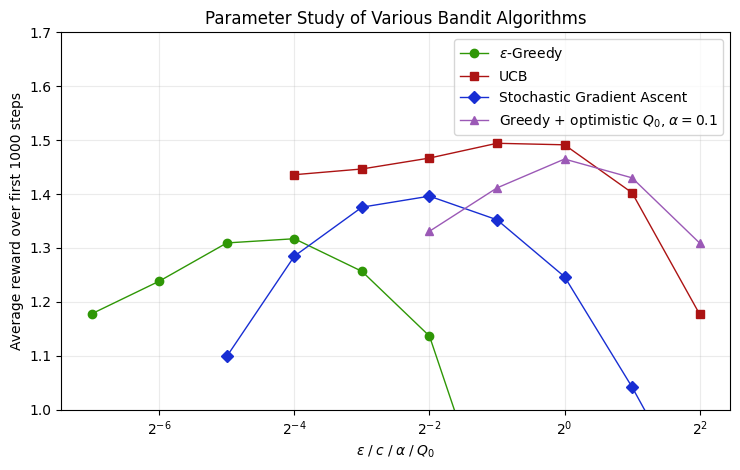

In [ ]:
tasks = 2000
iterations = 1000

base_env = {
    "seed": seed,
    "real_value_mean": 0,
    "type": "stationary",
    "reward_std": 1,
    "iterations": iterations,
    "num_of_bandits": k,
}

base_strategy = {
    "optimistic": False,
    "Q_0": 0.0,
    "value_estimate_update_rule": "mean",  
    "baseline": True,                      
    "alpha": 0.1,                         
}

def run_strategy(env_params, strat_params):
    avg, pct = Experiment.conduct_experiment(tasks, env_params, strat_params)
    return avg, pct


epsilon_vals       = [1/(2**i) for i in range(7, -1, -1)]  
learning_rate_vals = [1/(2**i) for i in range(5, -1, -1)] + [2, 4]  
c_vals             = [1/(2**i) for i in range(4, -1, -1)] + [2, 4]  

epsilon_results = []
c_results = []
learning_rate_results = []

for eps in epsilon_vals:
    env = copy.deepcopy(base_env)
    strat = copy.deepcopy(base_strategy)
    strat.update({
        "strategy": "epsilon_greedy",
        "epsilon": float(eps),
    })
    avg, _ = run_strategy(env, strat)
    epsilon_results.append(float(np.mean(avg)))

for c in c_vals:
    env = copy.deepcopy(base_env)
    strat = copy.deepcopy(base_strategy)
    strat.update({
        "strategy": "upper_confidence_bound",
        "c": float(c),
    })
    avg, _ = run_strategy(env, strat)
    c_results.append(float(np.mean(avg)))

for lr in learning_rate_vals:
    env = copy.deepcopy(base_env)
    strat = copy.deepcopy(base_strategy)
    strat.update({
        "strategy": "softmax_preference",
        "learning_rate_alpha": float(lr),
        "alpha": float(lr),      
        "baseline": True,
    })
    avg, _ = run_strategy(env, strat)
    learning_rate_results.append(float(np.mean(avg)))

Q_0_vals = [1/(2**i) for i in range(2, -1, -1)] + [2, 4]   
Q_0_results = []

for Q0 in Q_0_vals:
    env = copy.deepcopy(base_env)
    strat = {
        "strategy": "epsilon_greedy",
        "optimistic": True,
        "value_estimate_update_rule": "exponential_decay",  
        "epsilon": 0.0,
        "alpha": 0.1,
        "Q_0": float(Q0),
    }
    avg, _ = run_strategy(env, strat)
    Q_0_results.append(float(np.mean(avg)))

def sort_xy(xs, ys):
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    idx = np.argsort(xs)
    return xs[idx], ys[idx]

eps_x, eps_y = sort_xy(epsilon_vals, epsilon_results)
c_x, c_y = sort_xy(c_vals, c_results)
lr_x, lr_y = sort_xy(learning_rate_vals, learning_rate_results)
q0_x, q0_y = sort_xy(Q_0_vals, Q_0_results)

# --------- Plot ---------
colors = ["#2f9706", "#AC1313", "#182ed3", "#9b59b6"]
markers = ["o", "s", "D", "^"]

plt.figure(figsize=(7.5, 4.8))

plt.plot(eps_x, eps_y, marker=markers[0], linewidth=1.0, c=colors[0],
         label=r'$\varepsilon$-Greedy')
plt.plot(c_x, c_y, marker=markers[1], linewidth=1.0, c=colors[1],
         label=r'UCB')
plt.plot(lr_x, lr_y, marker=markers[2], linewidth=1.0, c=colors[2],
         label=r'Stochastic Gradient Ascent')
plt.plot(q0_x, q0_y, marker=markers[3], linewidth=1.0, c=colors[3],
         label=r'Greedy + optimistic $Q_0$, $\alpha=0.1$')

plt.title('Parameter Study of Various Bandit Algorithms')
plt.ylabel('Average reward over first 1000 steps')
plt.xlabel(r'$\varepsilon \;/\; c \;/\; \alpha \;/\; Q_0$')
plt.xscale('log', base=2)
plt.ylim(1.0, 1.7)
plt.grid(alpha=0.25, which='both')
plt.legend()
plt.tight_layout()
plt.show()


### Stationary vs. Non-stationary Bandits: Comparison of Simple Algorithms  
*(Extra experiment inspired by Ch. 2)*  

**Goal** — Compare algorithm behavior when true action values drift over time vs. remain fixed.

**Setup**
- 2,000 runs × 10,000 steps; $k = 10$  
- **Stationary:** $q_{*}(a) \sim \mathcal{N}(0, 1)$; rewards $R_t \sim \mathcal{N}(q_{*}(A_t), 1)$  
- **Non-stationary:** start $q_{*}(a) = 0$; each step  
  $$
  q_{*}(a) \leftarrow q_{*}(a) + \varepsilon_t,\quad \varepsilon_t \sim \mathcal{N}(0, 0.01^2)
  $$

**Algorithms**
1. **$\varepsilon$-greedy (sample-average)** — good for stationary; slow to adapt  
2. **$\varepsilon$-greedy (constant $\alpha$)** — tracks non-stationary rewards better  
3. **UCB** — deterministic exploration, best for stationary  
4. **Optimistic greedy** ($Q_0 > 0,\; \alpha = 0.1$) — fast early learning, poor under drift  
5. **Gradient bandit (softmax preferences)** — probabilistic policy; baseline reduces variance  

**Metrics**
- Average reward over time  
- % Optimal action (optional)  
- Moving-average smoothing for non-stationary tracking  

**Expected trends**
- **Stationary** → UCB & sample-average $\varepsilon$-greedy perform best  
- **Non-stationary** → constant-$\alpha$ $\varepsilon$-greedy & gradient bandit outperform others  
- **Optimistic greedy** improves early, then stagnates  


In [12]:
tasks = 2000
iterations = 1000

# Stationary version
env_parameters = {"seed": seed,  "real_value_mean": 0, "type": "stationary", "perturb": 0, "reward_std": 1, "iterations": iterations,  "num_of_bandits": k}
strategy_parameters = {"optimistic": False, "Q_0": 0, "value_estimate_update_rule": "mean", "baseline": True, "alpha": 0.1}

stat_epsilon_results = list()
stat_learning_rate_results = list()
stat_c_results = list()
stat_Q_0_results = list()

strategies = [{"strategy": "epsilon_greedy", "param": "epsilon", "param_val": 0.1, "param_results": stat_epsilon_results}, 
              {"strategy": "upper_confidence_bound", "param": "c", "param_val": 1, "param_results": stat_c_results},
              {"strategy": "softmax_preference", "param": "learning_rate_alpha", "param_val": 0.1, "param_results": stat_learning_rate_results}]

for strategy in strategies:    
    strategy_parameters["strategy"] = strategy["strategy"]
    strategy_parameters[strategy["param"]] = strategy["param_val"]
    average_reward, percentage_optimal_action = Experiment.conduct_experiment(tasks, env_parameters, strategy_parameters)
    strategy["param_results"].extend([average_reward, percentage_optimal_action])
    

strategy_parameters["strategy"] = "epsilon_greedy"
strategy_parameters["epsilon"] = 0
strategy_parameters["value_estimate_update_rule"] = "exponential_decay"
strategy_parameters["optimistic"] = True
strategy_parameters["Q_0"] = 1
average_reward, percentage_optimal_action = Experiment.conduct_experiment(tasks, env_parameters, strategy_parameters)
stat_Q_0_results.extend([average_reward, percentage_optimal_action])

100%|██████████| 2000/2000 [00:44<00:00, 45.10it/s]


In [13]:
# Nonstationary version, with perturb = 0.01
env_parameters = {"seed": seed,  "real_value_mean": 0, "type": "nonstationary", "perturb": 0.01, "reward_std": 1, "iterations": iterations,  "num_of_bandits": k}
strategy_parameters = {"optimistic": False,  "Q_0": 0, "value_estimate_update_rule": "mean", "baseline": True, "alpha": 0.1}

nonstat_epsilon_results = list()
nonstat_learning_rate_results = list()
nonstat_c_results = list()
nonstat_Q_0_results = list()

strategies[0]["param_results"] = nonstat_epsilon_results
strategies[1]["param_results"] = nonstat_c_results
strategies[2]["param_results"] = nonstat_learning_rate_results

for strategy in strategies:    
    strategy_parameters["strategy"] = strategy["strategy"]
    strategy_parameters[strategy["param"]] = strategy["param_val"]
    average_reward, percentage_optimal_action = Experiment.conduct_experiment(tasks, env_parameters, strategy_parameters)
    strategy["param_results"].extend([average_reward, percentage_optimal_action])
    
strategy_parameters["strategy"] = "epsilon_greedy"
strategy_parameters["epsilon"] = 0
strategy_parameters["value_estimate_update_rule"] = "exponential_decay"
strategy_parameters["optimistic"] = True
strategy_parameters["Q_0"] = 1
average_reward, percentage_optimal_action = Experiment.conduct_experiment(tasks, env_parameters, strategy_parameters)
nonstat_Q_0_results.extend([average_reward, percentage_optimal_action])

100%|██████████| 2000/2000 [00:46<00:00, 43.31it/s]


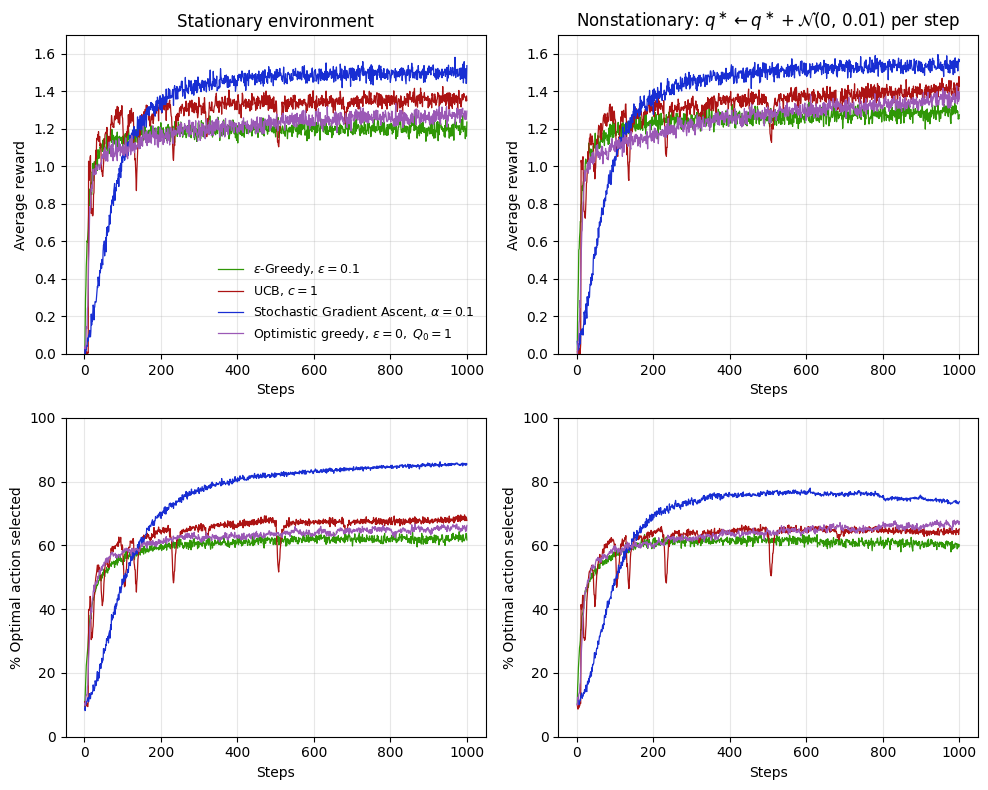

In [ ]:
stationary      = [stat_epsilon_results, stat_c_results, stat_learning_rate_results, stat_Q_0_results]
nonstationary   = [nonstat_epsilon_results, nonstat_c_results, nonstat_learning_rate_results, nonstat_Q_0_results]
stationary_sets = [stationary, nonstationary]

colors = ["#2f9706", "#AC1313", "#182ed3", "#9b59b6"]

labels = [
    r'$\varepsilon$-Greedy, $\varepsilon=0.1$',
    r'UCB, $c=1$',
    r'Stochastic Gradient Ascent, $\alpha=0.1$',
    r'Optimistic greedy, $\varepsilon=0,\ Q_0=1$'
]

ylabels = ['Average reward', '% Optimal action selected']

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=False)

axes[0, 0].set_title('Stationary environment')
axes[0, 1].set_title(r'Nonstationary: $q^\ast \leftarrow q^\ast + \mathcal{N}(0,\,0.01)$ per step')

for env_col, env_data in enumerate(stationary_sets):
    for row_metric in range(2):
        ax = axes[row_metric, env_col]
        for strat_idx in range(4):
            series = np.asarray(env_data[strat_idx][row_metric], dtype=float)
            x = np.arange(1, len(series) + 1)

            if row_metric == 1:
                y = series * 100.0
            else:
                y = series

            ax.plot(
                x, y,
                label=labels[strat_idx],
                color=colors[strat_idx],
                linewidth=0.9
            )

        ax.set_xlabel('Steps')
        ax.set_ylabel(ylabels[row_metric])
        if row_metric == 0:
            ax.set_ylim(0.0, 1.7)     
        else:
            ax.set_ylim(0, 100)      
        ax.grid(alpha=0.3)
        if row_metric == 0 and env_col == 0:
            ax.legend(fontsize=9, frameon=False, loc='lower right')

plt.tight_layout()
plt.show()